In [1]:
#------ 
# Project Name: fig S5 code
# Description : 
# Author: Tian Sang 
#------ 

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from typing import List, Optional
from matplotlib.ticker import FuncFormatter

# ------------------------ Style settings ------------------------ #

def set_global_style(font_family='Arial', font_size=12, legend_size=11):
    """Set global academic style: fonts, sizes, axes, legend."""
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    mpl.rcParams['font.family'] = font_family
    mpl.rcParams['axes.labelsize'] = font_size
    mpl.rcParams['axes.titlesize'] = font_size
    mpl.rcParams['xtick.labelsize'] = font_size - 1
    mpl.rcParams['ytick.labelsize'] = font_size - 1
    mpl.rcParams['legend.fontsize'] = legend_size
    mpl.rcParams['axes.spines.top'] = False
    mpl.rcParams['axes.spines.right'] = False
    mpl.rcParams['legend.frameon'] = False

# ------------------------ Main plotting function ------------------------ #

def plot_tsnr_distribution_multi(
    nii_paths,
    labels=None,
    bins=40,
    colors=None,
    alphas=None,
    ratio=(2, 3),          
    base_width=3.0,         
    vmax_pct=99.5,          
    edgecolor='gray',
    linewidth=0.2,
    show_mean=True,
):
    """
    Plot voxel tSNR histograms from multiple NIfTI files and optionally save as PDF.

    Args:
        nifti_paths: list of .nii/.nii.gz paths.
        labels: legend labels, defaults to "Image i".
        bins: histogram bins.
        colors: curve colors (hex or names).
        alphas: per-curve transparency.
        figsize: figure size (H, W).
        base_width: canvas width in inches.
        vmax_pct: upper percentile to clip extremes.
        save_path: optional path to save the figure.
    """
    if labels is None:
        labels = [f"Image {i+1}" for i in range(len(nii_paths))]
    if len(labels) != len(nii_paths):
        raise ValueError("labels 的长度必须与 nii_paths 一致。")

    fig_width  = base_width
    fig_height = base_width * (ratio[0] / ratio[1])
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.1f}"))

    for i, nii_path in enumerate(nii_paths):
        img  = nib.load(nii_path)
        data = img.get_fdata().astype(np.float32)

        tsnr = data[np.isfinite(data)].ravel()
        tsnr = tsnr[tsnr > 0]

        if tsnr.size == 0:
            print(f"[警告] {nii_path} 为空或无有效 tSNR 值，跳过。")
            continue

        vmax = np.percentile(tsnr, vmax_pct)
        tsnr = tsnr[tsnr <= vmax]

        color = colors[i] if (colors and i < len(colors)) else None
        alpha = alphas[i] if (alphas and i < len(alphas)) else 0.5

        ax.hist(
            tsnr,
            bins=bins,
            density=True,
            color=color,
            alpha=alpha,
            edgecolor=edgecolor,
            linewidth=linewidth,
            label=labels[i]
        )

        if show_mean:
            mean_val = float(np.mean(tsnr))
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
            y_top = ax.get_ylim()[1]
            ax.text(mean_val, y_top * 0.9, f"{mean_val:.1f}",
                    color=color if color else 'black',
                    ha='center', va='top', fontsize=8)

    ax.set_xlabel("tSNR")
    ax.set_ylabel("Voxel probability (%)")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    fig.tight_layout()

    return fig, ax


(<Figure size 300x360 with 1 Axes>,
 <Axes: xlabel='tSNR', ylabel='Voxel probability (%)'>)

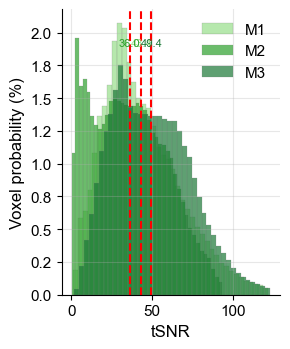

In [3]:
set_global_style()

nii_files = [
    './Fig2 figS5 tSNR results/M1_tSNR_mean.nii.gz',
    './Fig2 figS5 tSNR results/M2_tSNR_mean.nii.gz',
    './Fig2 figS5 tSNR results/M3_tSNR_mean.nii.gz'
]
labels = ["M1", "M2", "M3"]
colors = ["#98DF8A", "#2CA02C", "#1B7837"]
alphas = [0.7, 0.7, 0.7]

plot_tsnr_distribution_multi(
    nii_paths=nii_files,
    labels=labels,
    bins=40,
    colors=colors,
    alphas=alphas,
    ratio=(6, 5),
    base_width=3.0,
    vmax_pct=99.5
)